# 🔥 Laboratorio 02.3: Pronóstico de Gasto Calórico
### Separación de Calorías Activas (`active_kilocalories`), de Reposo (`resting_kilocalories`) y Totales (`total_kilocalories`)

---

## 🎯 Objetivo
Proyectar el balance energético diario del atleta separando:
1. **Calorías en Reposo (Tasa Metabólica Basal - BMR)**: Consumo celular basal vital.
2. **Calorías en Actividad**: Gasto dependiente del entrenamiento y movimiento diurno.
3. **Calorías Totales**: Consumo metabólico consolidado.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

df[["calendar_date", "active_kilocalories", "resting_kilocalories", "total_kilocalories"]].head()


,calendar_date,active_kilocalories,resting_kilocalories,total_kilocalories
0,2026-09-08,241.0,1876.0,2117.0
1,2026-09-09,258.0,1876.0,2134.0
2,2026-09-10,327.0,1876.0,2203.0
3,2026-09-11,448.0,1876.0,2324.0
4,2026-09-12,845.0,1876.0,2721.0


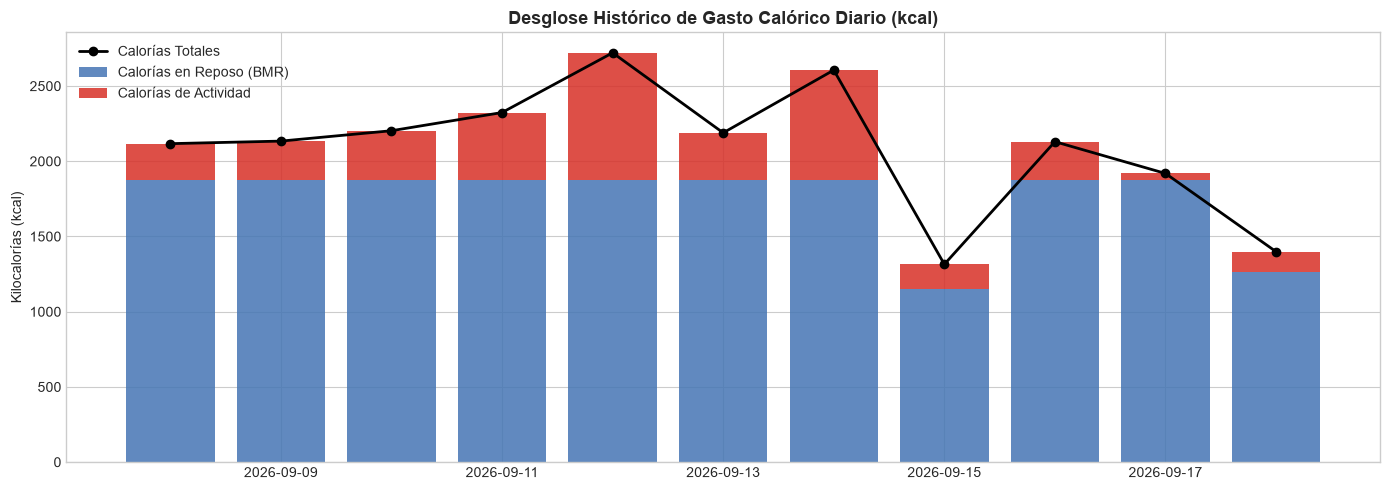

In [2]:
# Gráfico apilado de gasto calórico histórico
fig, ax = plt.subplots(figsize=(14, 5))

dates = df["calendar_date"]
ax.bar(dates, df["resting_kilocalories"], label="Calorías en Reposo (BMR)", color="#4575b4", alpha=0.85)
ax.bar(dates, df["active_kilocalories"], bottom=df["resting_kilocalories"], label="Calorías de Actividad", color="#d73027", alpha=0.85)
ax.plot(dates, df["total_kilocalories"], color="black", marker="o", linewidth=2, label="Calorías Totales")

ax.set_title("Desglose Histórico de Gasto Calórico Diario (kcal)", fontweight="bold", fontsize=13)
ax.set_ylabel("Kilocalorías (kcal)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


2026-09-18 17:47:00 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:47:00 | INFO     | src.analytics.time_series_models:269 - Prophet: Masked 5 anomalous days for 'active_kilocalories'.


2026-09-18 17:47:00 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 3.


2026-09-18 17:47:00 | INFO     | logging:1706 - Chain [1] start processing


🩺 Actividad: Bounds = (0.0, 3000.0) kcal


...

2026-09-18 17:47:01 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'total_kilocalories' (growth=logistic, bounds=(1215.0, 4500.0), anomalies_masked=0).


2026-09-18 17:47:01 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:47:01 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'total_kilocalories' (bounds=(1215.0, 4500.0), residual_sigma=361.59).


2026-09-18 17:47:01 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'total_kilocalories' with weights=(0.5, 0.5).


🩺 Total: Bounds = (1215.0, 4500.0) kcal


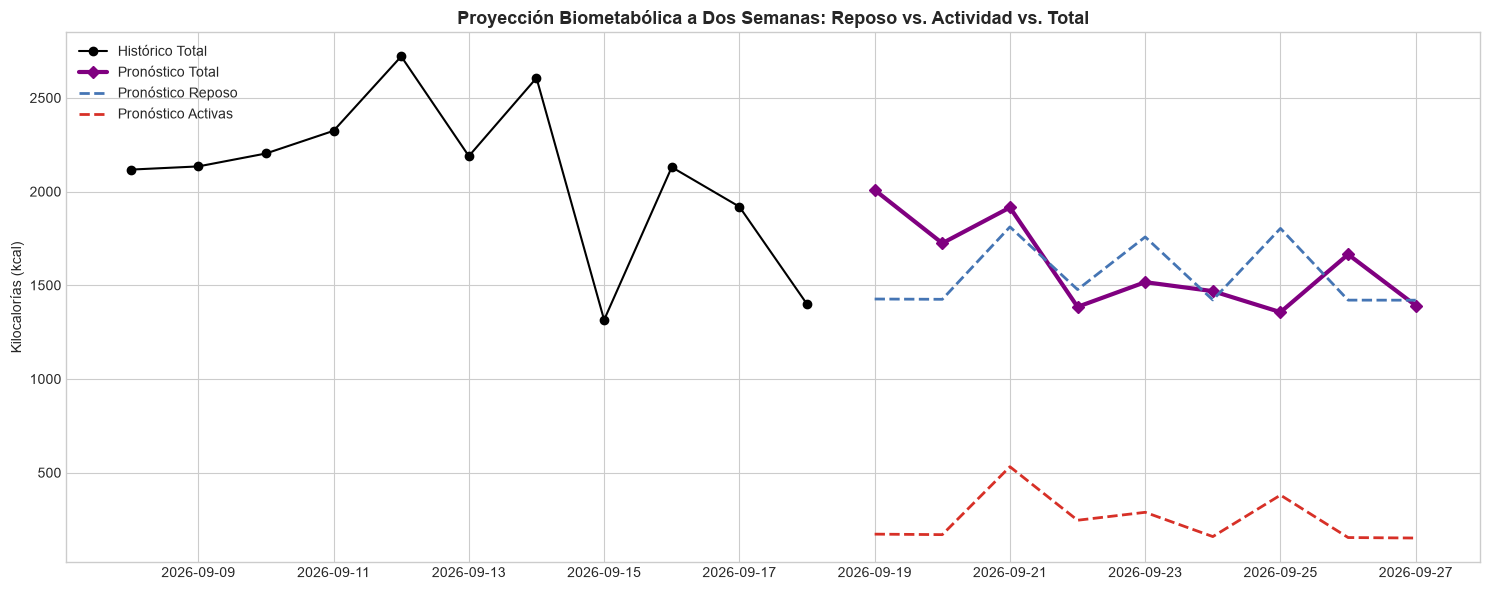

In [3]:
# Pronósticos separados para cada componente
horizon = 9
cal_cols = ["active_kilocalories", "resting_kilocalories", "total_kilocalories"]
cal_labels = ["Actividad", "Reposo (BMR)", "Total"]
cal_preds = {}

for col, lab in zip(cal_cols, cal_labels):
    b = compute_physiological_bounds(df[col], col)
    print(f"🩺 {lab}: Bounds = {b} kcal")
    ens = EnsembleBiometricForecaster(bounds=b).fit(df, col)
    cal_preds[col] = ens.predict(periods=horizon)

fut_mask = cal_preds["total_kilocalories"]["ds"] > df["calendar_date"].max()
fut_dates = cal_preds["total_kilocalories"].loc[fut_mask, "ds"]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df["calendar_date"], df["total_kilocalories"], "ko-", label="Histórico Total")
ax.plot(fut_dates, cal_preds["total_kilocalories"].loc[fut_mask, "yhat"], color="purple", linewidth=3, marker="D", label="Pronóstico Total")

ax.plot(fut_dates, cal_preds["resting_kilocalories"].loc[fut_mask, "yhat"], color="#4575b4", linewidth=2, linestyle="--", label="Pronóstico Reposo")
ax.plot(fut_dates, cal_preds["active_kilocalories"].loc[fut_mask, "yhat"], color="#d73027", linewidth=2, linestyle="--", label="Pronóstico Activas")

ax.set_title("Proyección Biometabólica a Dos Semanas: Reposo vs. Actividad vs. Total", fontweight="bold", fontsize=13)
ax.set_ylabel("Kilocalorías (kcal)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 💡 Conclusión y Hallazgos
- El gasto basal en reposo se proyecta con alta estabilidad (homeostasis energética ~1800-1900 kcal).
- Las calorías activas reflejan los ciclos semanales de entrenamiento del atleta.
